In [18]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load
import torch._dynamo
torch._dynamo.config.suppress_errors = True

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [19]:
import torch
from torch.utils.data import random_split
from torch.utils.data import DataLoader

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [20]:
import os
print(os.listdir('/kaggle/input/'))
print(os.listdir('/kaggle/input/notebooks/'))
print(os.listdir('/kaggle/input/notebooks/mehananagarur/neuro-cs-project'))

['models', 'datasets', 'notebooks']
['mehananagarur']
['__results__.html', '__notebook__.ipynb', '__results___files', '__output__.json', 'custom.css']


In [21]:
import os
for root, dirs, files in os.walk('/kaggle/input'):
    for file in files:
        if file.endswith('.pth'):
            print(os.path.join(root, file))

/kaggle/input/models/mehananagarur/model-augmemted/other/albumentation/1/model_augmented (1).pth


In [22]:
!pip install segmentation-models-pytorch albumentations nibabel anthropic -q

import os
print(os.listdir('/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/')[:5])

['BraTS20_Training_083', 'BraTS20_Training_337', 'BraTS20_Training_161', 'BraTS20_Training_198', 'BraTS20_Training_284']


In [23]:
DATA_PATH = '/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/'

In [24]:
first_patient = os.path.join(DATA_PATH, 'BraTS20_Training_083')
print(os.listdir(first_patient))

['BraTS20_Training_083_flair.nii', 'BraTS20_Training_083_t1.nii', 'BraTS20_Training_083_seg.nii', 'BraTS20_Training_083_t2.nii', 'BraTS20_Training_083_t1ce.nii']


In [25]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np

flair = nib.load(os.path.join(first_patient, 'BraTS20_Training_083_flair.nii'))
seg = nib.load(os.path.join(first_patient, 'BraTS20_Training_083_seg.nii'))

flair_data = flair.get_fdata()
seg_data = seg.get_fdata()

print("FLAIR shape:", flair_data.shape)
print("Seg shape:", seg_data.shape)
print("Unique seg values:", np.unique(seg_data))

FLAIR shape: (240, 240, 155)
Seg shape: (240, 240, 155)
Unique seg values: [0. 1. 2. 4.]


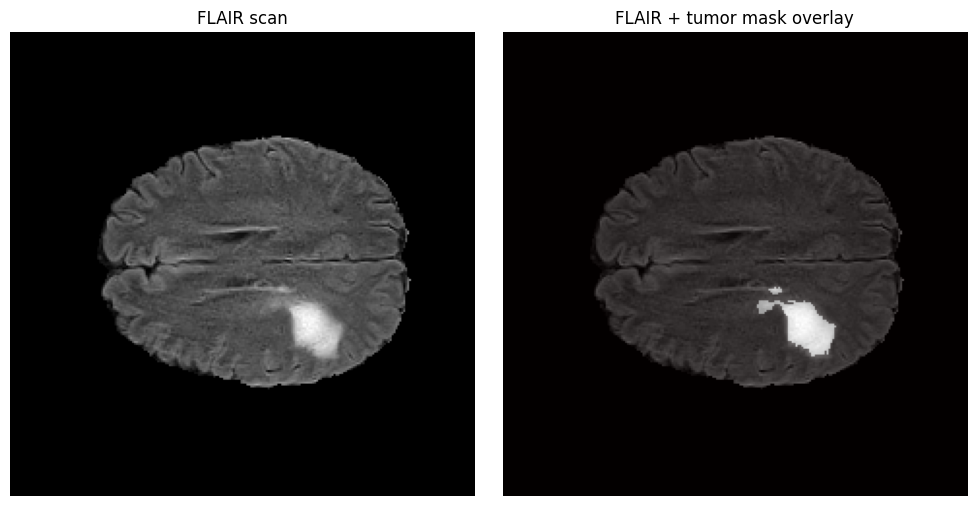

In [26]:
# roughly the middle of the 155 slices; tumor most likely to be visible here
slice_idx = 90 

# creates a figure with 1 row, 2 columns of plots side by side
# figsize sets the width and height in inches
# fig is the overall canvas, axes is the list of two individual plot panels
fig, axes = plt.subplots(1, 2, figsize=(10, 5)) 

# axes[0] is the left plot panel

# flair_data[:, :, slice_idx] slices the 3D array, : means everything in that dimension (all rows all cols)
# imshow displays the image and cmap renders it in a grayscale like a real MRI
axes[0].imshow(flair_data[:, :, slice_idx], cmap='gray')
# adds title and turns off axis tick marks
axes[0].set_title('FLAIR scan')
axes[0].axis('off')

# axes[1] is the right plot panel
# draws 2 images (flair and seg) with the seg overlaid on top of flair
#cmap = "hot" makes the tumor areas red/orange and alpha=0.4 makes it a bit transparent
axes[1].imshow(flair_data[:, :, slice_idx], cmap='gray')
axes[1].imshow(seg_data[:, :, slice_idx], cmap='hot', alpha=0.4)
axes[1].set_title('FLAIR + tumor mask overlay')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [27]:
folder_list = []
for i in os.listdir(DATA_PATH):
    if i.startswith('BraTS20_Training_'):
        if (os.path.exists(os.path.join(DATA_PATH, i, i + '_seg.nii'))):
            folder_list.append(os.path.join(DATA_PATH, i))

In [28]:
# make a transform pipeline (list of augmentations you want to randomly apply)
import albumentations as A

pipeline = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ElasticTransform(p=0.5),
    A.RandomBrightnessContrast(p=0.5),
])

In [29]:
from torch.utils.data import Dataset

class BraTSDataset:
    def __init__(self, folderList):
        self.folder_list = folderList
        self.valid_slices = []
        for patient_index, patient_path in enumerate(self.folder_list):
            patient_folder_name = os.path.basename(patient_path)
            patient_flair_path = os.path.join(patient_path, patient_folder_name + '_flair.nii')
            flair = nib.load(patient_flair_path)
            flair_data = flair.get_fdata()
            for slice_index in range(155):
                flair_slice = flair_data[:, :, slice_index]
                if np.max(flair_slice) > 0:
                    self.valid_slices.append((patient_index, slice_index))


    def __len__(self):
        return len(self.valid_slices)

    # returns the 2d image at the given image index
    def __getitem__(self, index):
        # index is the index of the photo if they were all listed as 1 list
        # every patient has 155 photos 
        #patient_index = index // len(self.valid_slices)
        # every slice is a multiple of 155 (mod) 
        #slice_index = index % len(self.valid_slices)

        # now though, we're using the list created in init
        patient_index, slice_index = self.valid_slices[index]

        patient_path = self.folder_list[patient_index]
        patient_folder_name = os.path.basename(patient_path)
        
        patient_flair_path = os.path.join(patient_path, patient_folder_name + '_flair.nii')
        patient_seg_path = os.path.join(patient_path, patient_folder_name + '_seg.nii')
        patient_t1ce_path = os.path.join(patient_path, patient_folder_name + '_t1ce.nii')
        
        flair = nib.load(patient_flair_path)
        seg = nib.load(patient_seg_path)
        t1ce = nib.load(patient_t1ce_path)
    
        flair_data = flair.get_fdata()
        seg_data = seg.get_fdata()
        t1ce_data = t1ce.get_fdata()

        flair_slice = flair_data[:, :, slice_index]
        flair_slice = (flair_slice - np.mean(flair_slice)) / (np.std(flair_slice) + 1e-8)
        flair_slice = np.pad(flair_slice, ((8, 8), (8, 8)), mode='constant', constant_values=0)

        seg_slice = (seg_data[:, :, slice_index] > 0).astype(np.uint8)
        seg_slice = np.pad(seg_slice, ((8, 8), (8, 8)), mode='constant', constant_values=0)

        transformed = pipeline(image=flair_slice, mask=seg_slice)
        
        t1ce_slice = t1ce_data[:, :, slice_index]
        t1ce_slice = (t1ce_slice - np.mean(t1ce_slice)) / (np.std(t1ce_slice) + 1e-8)
        t1ce_slice = np.pad(t1ce_slice, ((8, 8), (8, 8)), mode='constant', constant_values=0)

        
        return (np.stack([transformed['image'], t1ce_slice], axis=0), transformed['mask'][np.newaxis, :, :])    

In [30]:
dataset = BraTSDataset(folder_list)

In [31]:
sample_image, sample_mask = dataset[0]
print(sample_image.shape)
print(sample_mask.shape)

(2, 256, 256)
(1, 256, 256)


In [32]:
print(len(dataset))

flair_slice, seg_slice = dataset[0]
print(flair_slice.shape)
print(seg_slice.shape)
print(flair_slice.min(), flair_slice.max())
print(np.unique(seg_slice))

flair_slice, seg_slice = dataset[25000]
print(np.unique(seg_slice))

50706
(2, 256, 256)
(1, 256, 256)
-0.07949413891487062 30.03213259891021
[0]
[0 1]


In [33]:
len_train = int(len(dataset) * 0.8)
len_test = int(len(dataset) * 0.1)
len_val = len(dataset) - len_train - len_test

train_dataset, val_dataset, test_dataset = random_split(dataset, [len_train, len_val, len_test])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

In [34]:
flair_batch, seg_batch = next(iter(train_loader))
print(flair_batch.shape)
print(seg_batch.shape)

torch.Size([32, 2, 256, 256])
torch.Size([32, 1, 256, 256])


In [35]:
import torch.nn as nn

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1), nn.BatchNorm2d(out_channels), nn.ReLU(), nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1), nn.BatchNorm2d(out_channels), nn.ReLU())

    def forward(self, x):
        return self.conv(x)
        


In [36]:
class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = DoubleConv(1, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)

        self.bottleneck = DoubleConv(512, 1024)

        
        self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(1024, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(128, 64)

        self.final = nn.Conv2d(64, 1, kernel_size=1) # outputs 1 channel, tumor or not

        self.pool = nn.MaxPool2d(2)
        
    def forward(self, x):
        e1 = self.enc1(x) # passes the raw input image (240x240) through 1st double convolution and channels go from 1->64
        e2 = self.enc2(self.pool(e1)) # MaxPool shrinks 240x240 -> 120x120 and channels goes from 64->128
        e3 = self.enc3(self.pool(e2)) # shrinks to 60x60 & channels 128->256
        e4 = self.enc4(self.pool(e3)) # 60x60 -> 30x30 & 256->512
        bn = self.bottleneck(self.pool(e4)) # 15x15 & 512->1024

        # even though up4 is a class instance, in Python, doing this calls the __call__ method, and in nn.Module, __call__ calls forward()
        x = self.up4(bn) # ConvTranspose2d doubles spatial size from 15x15 -> 30x30, channels 1024->512
        x = torch.cat([x, e4], dim=1) # skip connection -> e4 was saved earlier with 30x30 & 512  & concatenation along dim=1 (channel dimension) gives 30
        x = self.dec4(x) # decoder now has the abstract features and high res detail, so this takes 1024 channels -> 512
        
        x = self.up3(x)
        x = torch.cat([x, e3], dim=1)
        x = self.dec3(x)

        x = self.up2(x)
        x = torch.cat([x, e2], dim=1)
        x = self.dec2(x)

        x = self.up1(x)
        x = torch.cat([x, e1], dim=1)
        x = self.dec1(x)

        return self.final(x) # final answer
        

In [37]:
##import torch
##model = UNet()
##test_input = torch.randn(1, 1, 240, 240)
##output = model(test_input)
##print(output.shape)  # should print torch.Size([1, 1, 240, 240])

"""
import segmentation_models_pytorch as smp

model = smp.Unet(
    encoder_name='resnet34',
    encoder_weights='imagenet',
    in_channels=2,
    classes=1,
)
model.to('cuda')
"""


# attention varient
!pip install segmentation-models-pytorch==0.3.3 -q
import segmentation_models_pytorch as smp

model = smp.Unet(
    encoder_name='resnet34',
    encoder_weights='imagenet',
    in_channels=2,
    classes=1,
    decoder_attention_type="scse",
)
model.to('cuda')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 4.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.5/68.5 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.7/106.7 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 76.6 MB/s eta 0:00:00
Downloading: "https://download.pytorch.org/models/resnet34-333f7ec4.pth" to /root/.cache/torch/hub/checkpoints/resnet34-333f7ec4.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 496MB/s]


Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(2, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

In [38]:
def diceLoss(pred, target):
    pred = torch.sigmoid(pred)
    intersection = (pred * target).sum(dim=(2, 3))
    dice = (2 * intersection) / (pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3)) + 1e-6)
    return 1 - dice.mean()  

In [39]:
def combined_loss(pred, target):
    # nn.BCEWithLogitsLoss() returns a class and that's why we need two parentheses
    return nn.BCEWithLogitsLoss()(pred, target) + diceLoss(pred, target)

In [40]:
import os
print(os.path.exists('/kaggle/working/model_augmented.pth'))

False


In [49]:
    
import torch.optim as optim 
#model.load_state_dict(torch.load('/kaggle/working/model_augmented.pth'))
#model.load_state_dict(torch.load('/kaggle/input/notebooks/mehananagarur/neuro-cs-project/model_augmented.pth'))
model.load_state_dict(torch.load('/kaggle/input/models/mehananagarur/albumentation_35/pytorch/default/1/model_augmented (2).pth'))


model.to('cuda') # moves all the model weights from CPU to GPU
optimizer = optim.Adam(model.parameters(), lr=1e-5) # creates the Adam optimizer, which tells it which weights to update (right now every with in UNet), and how big each step should be (right now 0.0001)
count = 0      
patience = 3  
prev_val_loss = 0.6416
   
for epoch in range(5): # runs training loop (every slice) 30 times
    model.train() # puts the model in training mode
    total_loss = 0 
    for i, (flair_batch, seg_batch) in enumerate(train_loader): # for each slice that's stored in the data loader (16 slices and 16 masks)
        flair_batch = flair_batch.to('cuda').float()
        seg_batch = seg_batch.to('cuda').float()
        pred = model(flair_batch) # runs the 16 slices through entire UNet, encoder bottleneck decoder skip connections and then returns 16 predicted masks
        loss = combined_loss(pred, seg_batch) # compares the 16 predicted masks and returns 1 number about how wrong the model was
        loss.backward() # backpropagation
        optimizer.step() # updates every weight using its gradient (learning step)
        optimizer.zero_grad() # clears all the gradients so the next batch is clean
        total_loss += loss.item()
        if i % 500 == 0:
            print("done with 500 train batches")
    total_val_loss = 0
    model.eval()  
    with torch.no_grad():
        for i, (flair_batch, seg_batch) in enumerate(val_loader): # for each slice that's stored in data loader for validation
            flair_batch = flair_batch.to('cuda').float()
            seg_batch = seg_batch.to('cuda').float()
            pred = model(flair_batch)
            val_loss = combined_loss(pred, seg_batch)
            total_val_loss += val_loss.item()
            if i % 500 == 0:
                print("done with 500 val batches")

        avg_val_loss = total_val_loss / len (val_loader)

        if (avg_val_loss < prev_val_loss):
            torch.save(model.state_dict(), 'model.pth')
            #torch.save(model.state_dict(), '/kaggle/working/model.pth')
            #torch.save(model.state_dict(), '/kaggle/working/model_flair_t1ce.pth')
            #torch.save(model.state_dict(), '/kaggle/working/model_attention.pth')
            torch.save(model.state_dict(), '/kaggle/working/model_augmented.pth')
   
            count = 0
            prev_val_loss = avg_val_loss
       
        else:
            count += 1
  
    if count >= patience:         
        break        
        
    avg_loss = total_loss / len (train_loader)
    print(f"Epoch {epoch}, Avg Train Loss: {avg_loss:.4f}, Avg Val Loss: {avg_val_loss:.4f}")
     

done with 500 train batches
done with 500 train batches
done with 500 train batches
done with 500 val batches
Epoch 0, Avg Train Loss: 0.6384, Avg Val Loss: 0.6439
done with 500 train batches
done with 500 train batches
done with 500 train batches
done with 500 val batches
Epoch 1, Avg Train Loss: 0.6372, Avg Val Loss: 0.6436
done with 500 train batches
done with 500 train batches
done with 500 train batches
done with 500 val batches
Epoch 2, Avg Train Loss: 0.6376, Avg Val Loss: 0.6428
done with 500 train batches
done with 500 train batches
done with 500 train batches
done with 500 val batches
Epoch 3, Avg Train Loss: 0.6370, Avg Val Loss: 0.6423
done with 500 train batches
done with 500 train batches
done with 500 train batches
done with 500 val batches
Epoch 4, Avg Train Loss: 0.6357, Avg Val Loss: 0.6416


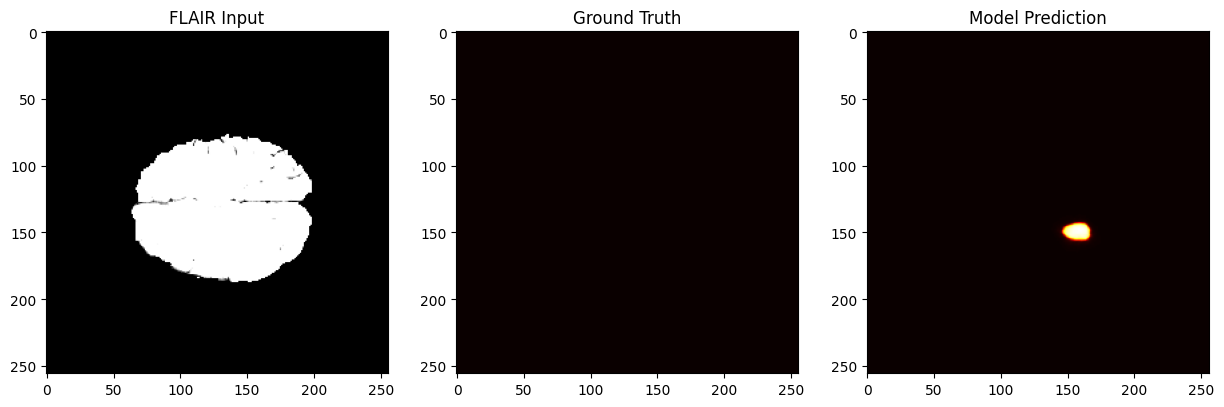

In [48]:
#model.load_state_dict(torch.load('/kaggle/input/notebooks/mehananagarur/neuro-cs-project/model.pth'))
#model.load_state_dict(torch.load('/kaggle/working/model.pth'))
#model.load_state_dict(torch.load('/kaggle/working/model_flair_t1ce.pth'))
#model.load_state_dict(torch.load('/kaggle/working/model_attention.pth'))
#model.load_state_dict(torch.load('/kaggle/input/notebooks/mehananagarur/neuro-cs-project/model_augmented.pth'))
#model.load_state_dict(torch.load('/kaggle/working/model_augmented.pth'))   
model.load_state_dict(torch.load('/kaggle/input/models/mehananagarur/albumentation_35/pytorch/default/1/model_augmented (2).pth'))

model.eval()   
with torch.no_grad():
    flair_batch, seg_batch = next(iter(val_loader))
    flair_batch = flair_batch.to('cuda').float()
    pred = torch.sigmoid(model(flair_batch))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(flair_batch[0, 0].cpu(), cmap='gray')
axes[0].set_title('FLAIR Input')
axes[1].imshow(seg_batch[0, 0], cmap='hot')
axes[1].set_title('Ground Truth')
axes[2].imshow(pred[0, 0].cpu(), cmap='hot')
axes[2].set_title('Model Prediction')
plt.show()

In [44]:
def dice_score(pred, target, threshold=0.5):
    # Converts raw model outputs to a binary mask. 
    # sigmoid squashes values to 0-1, then > 0.5 turns it into True/False 
    #nfor each pixel (is this tumor or not), then .float() converts True→1, False→0.
    pred = (torch.sigmoid(pred) > threshold).float()
    # Computes |A ∩ B| — pixels that are 1 in both predicted and ground truth masks. 
    # sum(dim=(2,3 )) adds up over height and width, keeping batch separate.
    intersection = (pred * target).sum(dim=(2, 3))
    dice = (2 * intersection) / (pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3)) + 1e-6)
    #Averages across the batch and converts from tensor to a plain Python number.
    return dice.mean().item()

model.eval()
total_dice = 0
with torch.no_grad():
    # Sets model to evaluation mode and initializes a running total.
    # Loops over the test set with gradients disabled — same pattern as your val loop.
    # Accumulates the Dice score across all batches.
    # Averages across all batches to get the final score.
    for flair_batch, seg_batch in test_loader:
        flair_batch = flair_batch.to('cuda').float()
        seg_batch = seg_batch.to('cuda').float()
        pred = model(flair_batch)
        total_dice += dice_score(pred, seg_batch)

avg_dice = total_dice / len(test_loader)
print(f"Test Set Dice Score: {avg_dice:.4f}")

Test Set Dice Score: 0.3747


In [ ]:
"""
# to draw loss curve
import torch.optim as optim

model.to('cuda') # moves all the model weights from CPU to GPU
optimizer = optim.Adam(model.parameters(), lr=1e-4) # creates the Adam optimizer, which tells it which weights to update (right now every with in UNet), and how big each step should be (right now 0.0001)
count = 0
patience = 3
prev_val_loss = float('inf')

trainLosses = []
valLosses = []

for epoch in range(5):
    model.train() # puts the model in training mode
    total_loss = 0
    for i, (flair_batch, seg_batch) in enumerate(train_loader): # for each slice that's stored in the data loader (16 slices and 16 masks)
        flair_batch = flair_batch.to('cuda').float()
        seg_batch = seg_batch.to('cuda').float()
        pred = model(flair_batch) # runs the 16 slices through entire UNet, encoder bottleneck decoder skip connections and then returns 16 predicted masks
        loss = combined_loss(pred, seg_batch) # compares the 16 predicted masks and returns 1 number about how wrong the model was
        loss.backward() # backpropagation
        optimizer.step() # updates every weight using its gradient (learning step)
        optimizer.zero_grad() # clears all the gradients so the next batch is clean
        total_loss += loss.item()
        if i % 500 == 0:
            print("done with 500 train batches")
    total_val_loss = 0
    model.eval()
    with torch.no_grad():
        for i, (flair_batch, seg_batch) in enumerate(val_loader): # for each slice that's stored in data loader for validation
            flair_batch = flair_batch.to('cuda').float()
            seg_batch = seg_batch.to('cuda').float()
            pred = model(flair_batch)
            val_loss = combined_loss(pred, seg_batch)
            total_val_loss += val_loss.item()
            if i % 500 == 0:
                print("done with 500 val batches")

        avg_val_loss = total_val_loss / len (val_loader)
        valLosses.append(avg_val_loss)
        
        if (avg_val_loss < prev_val_loss):
            torch.save(model.state_dict(), 'model.pth')
            torch.save(model.state_dict(), '/kaggle/working/model.pth')
            count = 0
            prev_val_loss = avg_val_loss
    
        else:
            count += 1
            
    if count >= patience:
        break 

    avg_loss = total_loss / len (train_loader)
    trainLosses.append(avg_loss)
    print(f"Epoch {epoch}, Avg Train Loss: {avg_loss:.4f}, Avg Val Loss: {avg_val_loss:.4f}")
    """

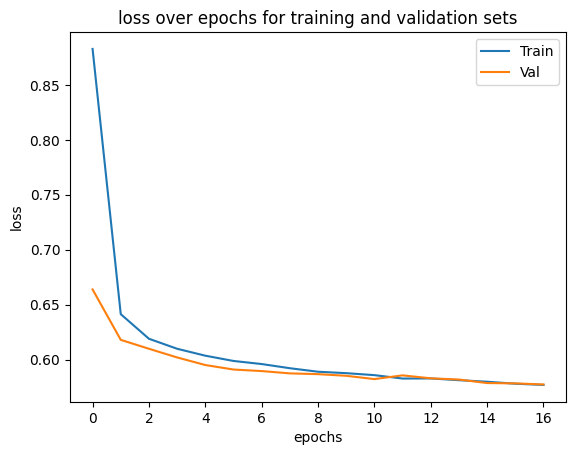

In [46]:
# hard code the losses instead through the log from prev night

import matplotlib.pyplot as plt

train_losses = [0.7528, 0.6302, 0.6178, 0.6101, 0.6044, 0.5996, 0.5966, 0.5937, 0.5908, 0.5884, 0.5871, 0.5842, 0.5830, 0.5821, 0.5795, 0.5788]
val_losses = [0.6275, 0.6205, 0.6062, 0.6073, 0.5985, 0.5964, 0.5911, 0.5934, 0.5889, 0.5883, 0.5856, 0.5941, 0.5850, 0.5805, 0.5828, 0.5808]

train_losses = [0.8827, 0.6414, 0.6190, 0.6099, 0.6036, 0.5988, 0.5960, 0.5922, 0.5890, 0.5877, 0.5859, 0.5828, 0.5829, 0.5813, 0.5799, 0.5781, 0.5770]
val_losses = [0.6639, 0.6180, 0.6099, 0.6020, 0.5951, 0.5910, 0.5896, 0.5875, 0.5868, 0.5853, 0.5823, 0.5857, 0.5830, 0.5819, 0.5787, 0.5784, 0.5774]

plt.plot(train_losses)
plt.plot(val_losses)
plt.legend(['Train', 'Val'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.title('loss over epochs for training and validation sets')
plt.show()
